### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("default")

In [3]:
fund["amfi_code"].duplicated().sum()

np.int64(0)

In [4]:
fund["amfi_code"].nunique(), len(fund)

(40, 40)

### Load Datasets

In [2]:
fund = pd.read_csv("../data/processed/clean_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

benchmark = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

### Dataset Overview

In [4]:
print("Fund:", fund.shape)
print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)

Fund: (40, 15)
NAV: (46000, 3)
Performance: (40, 20)
Benchmark: (8050, 3)


In [5]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [6]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,negative_sharpe
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False


In [8]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


## Task 1: Compute Daily Returns

This analysis computes the daily returns for all mutual fund schemes using the formula:

**Daily Return = (Current NAV / Previous NAV) - 1**

The distribution of daily returns is visualized to validate whether the returns follow a reasonable pattern.

#### Convert Date

In [11]:
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


#### Sort Data

In [12]:
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


#### Compute Daily Returns

In [13]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


#### Validate Distribution

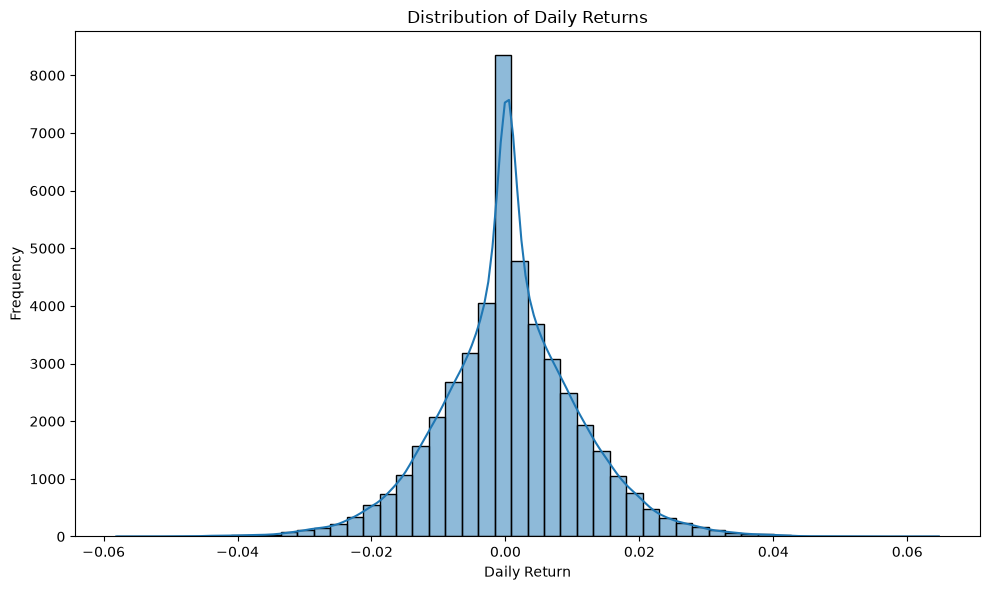

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../reports/charts/daily_return_distribution.png", dpi=300)

plt.show()

#### Summary Statistics

In [15]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

## Task 2: Compute CAGR (1 Year, 3 Years, 5 Years)

This analysis calculates the Compound Annual Growth Rate (CAGR) for 1-year, 3-year, and 5-year periods for all mutual fund schemes and creates a comparison table.

#### Select Required Columns

In [25]:
cagr_df = performance[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]]

cagr_df.head()

,amfi_code,scheme_name,fund_house,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,5.34,6.07,5.43


#### Sort by 3-Year Return

In [26]:
cagr_df = cagr_df.sort_values(
    by="return_3yr_pct",
    ascending=False
)

cagr_df.head(10)

,amfi_code,scheme_name,fund_house,return_1yr_pct,return_3yr_pct,return_5yr_pct
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,20.59,23.14,21.82
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,24.93,22.38,23.80
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,21.97,20.98,22.62
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,21.30,20.15,21.88
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,20.20,20.08,20.61
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,17.12,18.23,17.75
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,14.02,18.08,17.55
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,14.12,17.16,19.00
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,15.43,16.58,17.69


#### Save Comparison Table

In [27]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

#### Top 10 Funds Chart

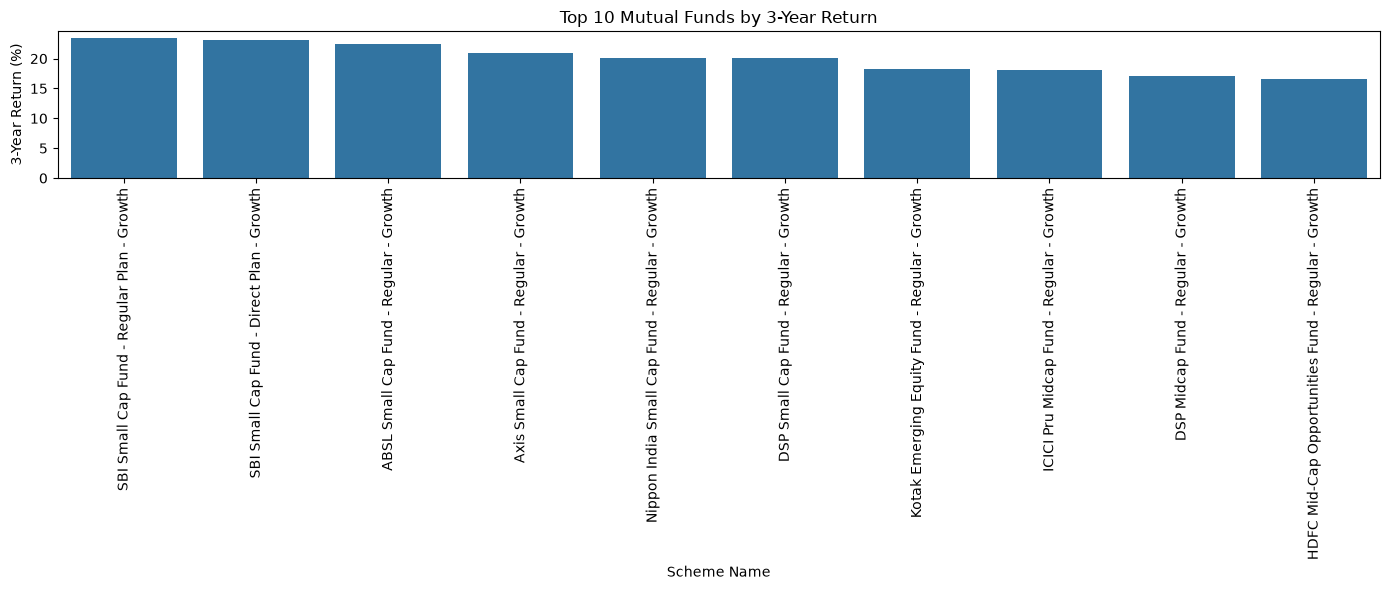

In [28]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=cagr_df.head(10),
    x="scheme_name",
    y="return_3yr_pct"
)

plt.xticks(rotation=90)

plt.title("Top 10 Mutual Funds by 3-Year Return")

plt.xlabel("Scheme Name")

plt.ylabel("3-Year Return (%)")

plt.tight_layout()

plt.savefig("../reports/charts/cagr_comparison.png", dpi=300)

plt.show()

#### Top 10 Comparison Table

In [29]:
cagr_df.head(10)

,amfi_code,scheme_name,fund_house,return_1yr_pct,return_3yr_pct,return_5yr_pct
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,20.59,23.14,21.82
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,24.93,22.38,23.80
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,21.97,20.98,22.62
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,21.30,20.15,21.88
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,20.20,20.08,20.61
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,17.12,18.23,17.75
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,14.02,18.08,17.55
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,14.12,17.16,19.00
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,15.43,16.58,17.69


## Sharpe Ratio

#### Risk-Free Rate

In [32]:
risk_free_rate = 0.065

#### Calculate Daily Returns

In [39]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

#### Calculate Sharpe Ratio

In [41]:
sharpe_list = []

for code in nav["amfi_code"].unique():

    fund_returns = nav.loc[
        nav["amfi_code"] == code,
        "daily_return"
    ].dropna()

    mean_return = fund_returns.mean()

    std_return = fund_returns.std()

    sharpe = ((mean_return * 252) - risk_free_rate) / (std_return * np.sqrt(252))

    sharpe_list.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe
    })

#### Create DataFrame

In [42]:
sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


#### Merge Scheme Names

In [43]:
sharpe_df = sharpe_df.merge(

    fund[["amfi_code", "scheme_name"]],

    on="amfi_code"

)

sharpe_df.head()

,amfi_code,Sharpe_Ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


#### Rank Funds

In [44]:
sharpe_df = sharpe_df.sort_values(

    by="Sharpe_Ratio",

    ascending=False

)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


#### Save CSV

In [45]:
sharpe_df.to_csv(

    "../reports/sharpe_ratio.csv",

    index=False

)

#### Bar Chart

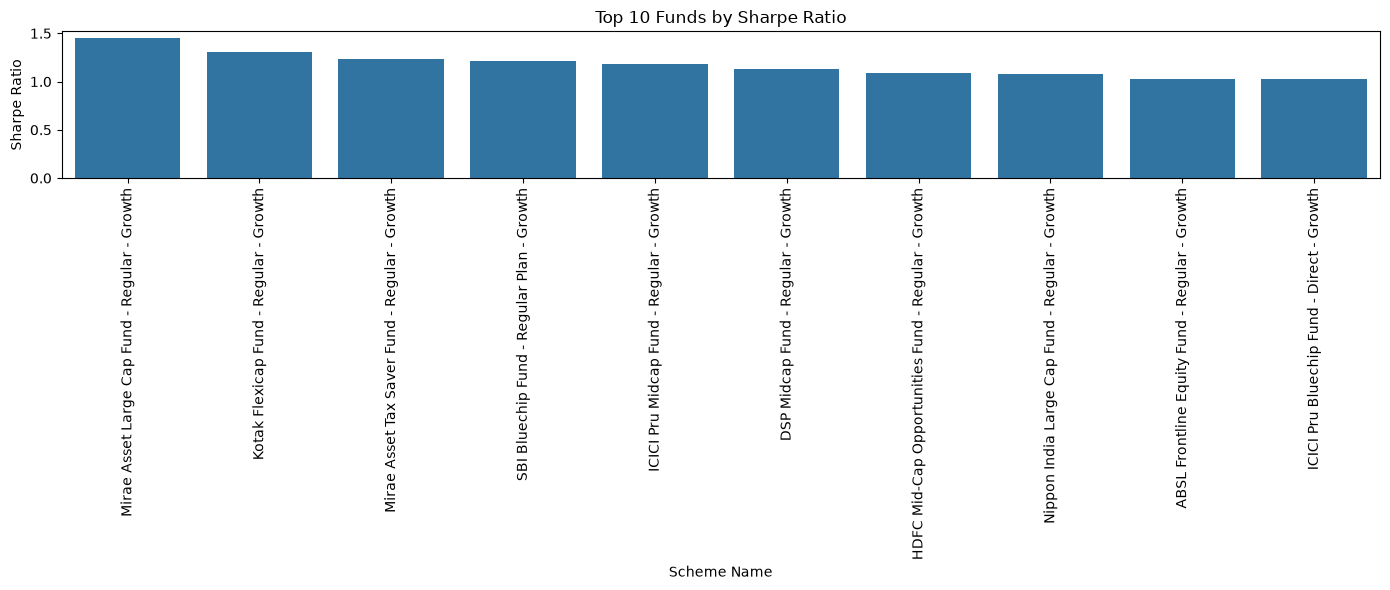

In [46]:
plt.figure(figsize=(14,6))

sns.barplot(

    data=sharpe_df.head(10),

    x="scheme_name",

    y="Sharpe_Ratio"

)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Scheme Name")

plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig("../reports/charts/sharpe_ratio.png", dpi=300)

plt.show()

## Sortino Ratio

#### Risk-Free Rate

In [47]:
risk_free_rate = 0.065

#### Daily Returns

In [48]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

#### Calculate Sortino Ratio

In [49]:
sortino_list = []

for code in nav["amfi_code"].unique():

    fund_returns = nav.loc[
        nav["amfi_code"] == code,
        "daily_return"
    ].dropna()

    annual_return = fund_returns.mean() * 252

    downside_returns = fund_returns[fund_returns < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (annual_return - risk_free_rate) / downside_std

    sortino_list.append({
        "amfi_code": code,
        "sortino_ratio": sortino
    })

#### Create DataFrame

In [50]:
sortino_df = pd.DataFrame(sortino_list)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


#### Merge Scheme Name

In [51]:
sortino_df = sortino_df.merge(

    fund[["amfi_code", "scheme_name"]],

    on="amfi_code"

)

sortino_df.head()

,amfi_code,sortino_ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


#### Rank Funds

In [52]:
sortino_df["Rank"] = sortino_df["sortino_ratio"].rank(
    ascending=False,
    method="dense"
).astype("Int64")

sortino_df = sortino_df.sort_values("Rank")

sortino_df.head(10)

,amfi_code,sortino_ratio,scheme_name,Rank
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,1
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,2
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,3
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,4
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,5
38,149323,1.875101,DSP Midcap Fund - Regular - Growth,6
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,7
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,9
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,10


#### Save CSV

In [53]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

#### Bar Chart

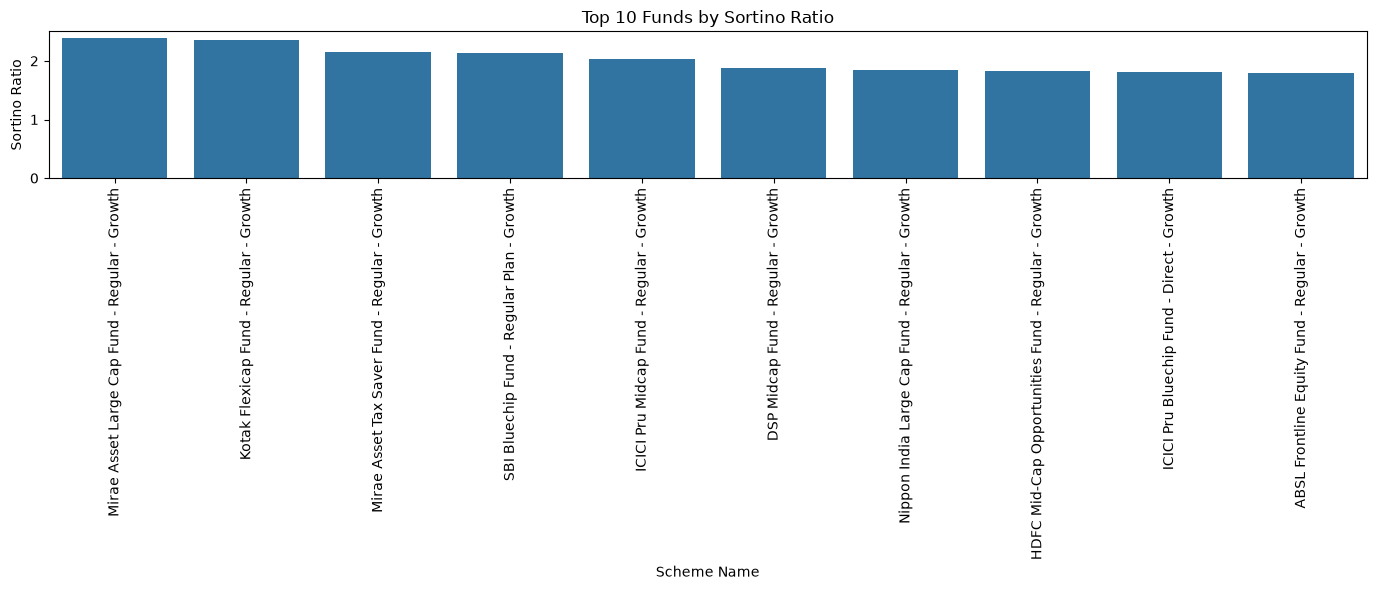

In [54]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=sortino_df.head(10),
    x="scheme_name",
    y="sortino_ratio"
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Scheme Name")

plt.ylabel("Sortino Ratio")

plt.tight_layout()

plt.savefig("../reports/charts/sortino_ratio.png", dpi=300)

plt.show()

## Alpha & Beta

In [55]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [56]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


#### Convert Date

In [57]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

#### Calculate Benchmark Daily Returns

In [58]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


#### Calculate Fund Daily Returns

In [59]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

#### Merge Fund Returns with Benchmark Returns

In [60]:
merged = pd.merge(

    nav,

    nifty100[["date", "benchmark_return"]],

    on="date",

    how="inner"

)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


#### Calculate Alpha & Beta

In [61]:
alpha_beta = []

for code in merged["amfi_code"].unique():

    df = merged[merged["amfi_code"] == code].dropna()

    if len(df) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(

        df["benchmark_return"],

        df["daily_return"]

    )

    alpha_beta.append({

        "amfi_code": code,

        "alpha": intercept * 252,

        "beta": slope

    })

#### Create DataFrame

In [62]:
alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


#### Merge Scheme Name

In [63]:
alpha_beta_df = alpha_beta_df.merge(

    fund[["amfi_code", "scheme_name"]],

    on="amfi_code"

)

alpha_beta_df.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


#### Save CSV

In [64]:
alpha_beta_df.to_csv(

    "../reports/alpha_beta.csv",

    index=False

)

#### Beta Chart

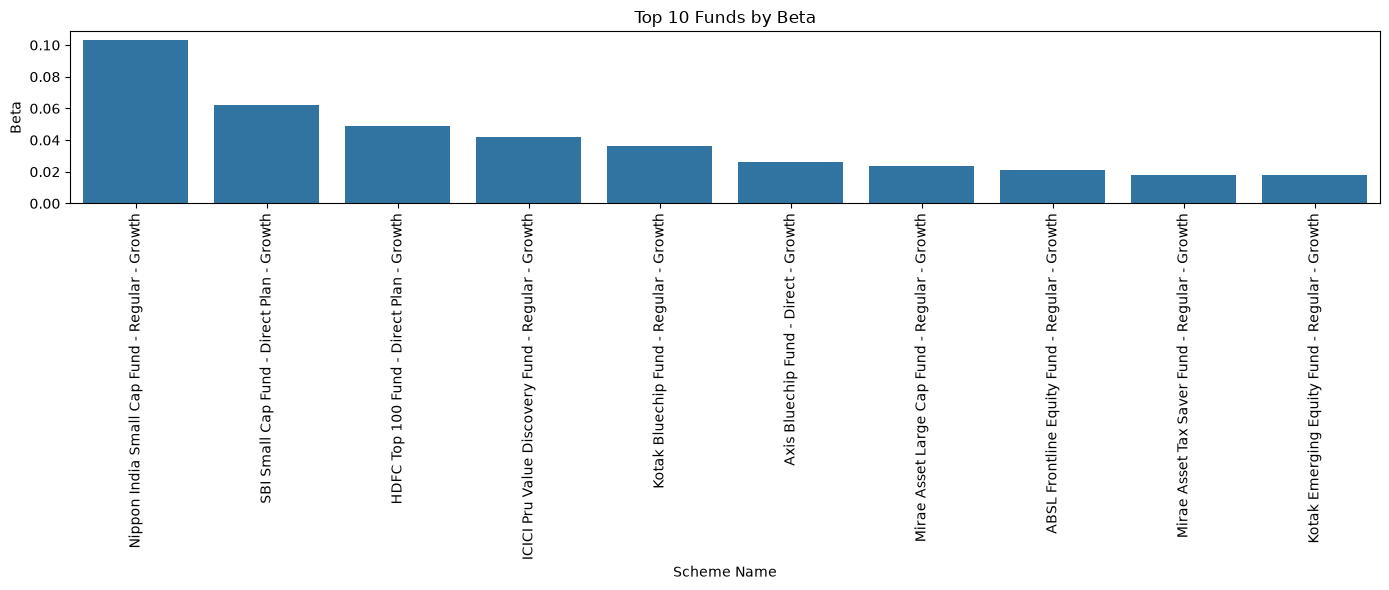

In [65]:
plt.figure(figsize=(14,6))

top_beta = alpha_beta_df.sort_values(
    "beta",
    ascending=False
).head(10)

sns.barplot(
    data=top_beta,
    x="scheme_name",
    y="beta"
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Beta")

plt.xlabel("Scheme Name")

plt.ylabel("Beta")

plt.tight_layout()

plt.savefig("../reports/charts/beta_comparison.png", dpi=300)

plt.show()

## Maximum Drawdown

#### Sort NAV Data

In [66]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

#### Calculate Running Maximum & Drawdown

In [67]:
nav["running_max"] = nav.groupby("amfi_code")["nav"].cummax()

nav["drawdown"] = (nav["nav"] / nav["running_max"]) - 1

nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


#### Calculate Maximum Drawdown for Each Fund

In [68]:
max_dd = nav.groupby("amfi_code")["drawdown"].min().reset_index()

max_dd.rename(
    columns={"drawdown": "max_drawdown"},
    inplace=True
)

max_dd.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


#### Merge Scheme Names

In [69]:
max_dd = max_dd.merge(

    fund[["amfi_code", "scheme_name"]],

    on="amfi_code"

)

max_dd.head()

,amfi_code,max_drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


#### Rank Funds

In [71]:
max_dd = max_dd.sort_values("max_drawdown")

max_dd.head(10)

,amfi_code,max_drawdown,scheme_name
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,Axis Bluechip Fund - Direct - Growth


#### Save CSV

In [72]:
max_dd.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

#### Visualization

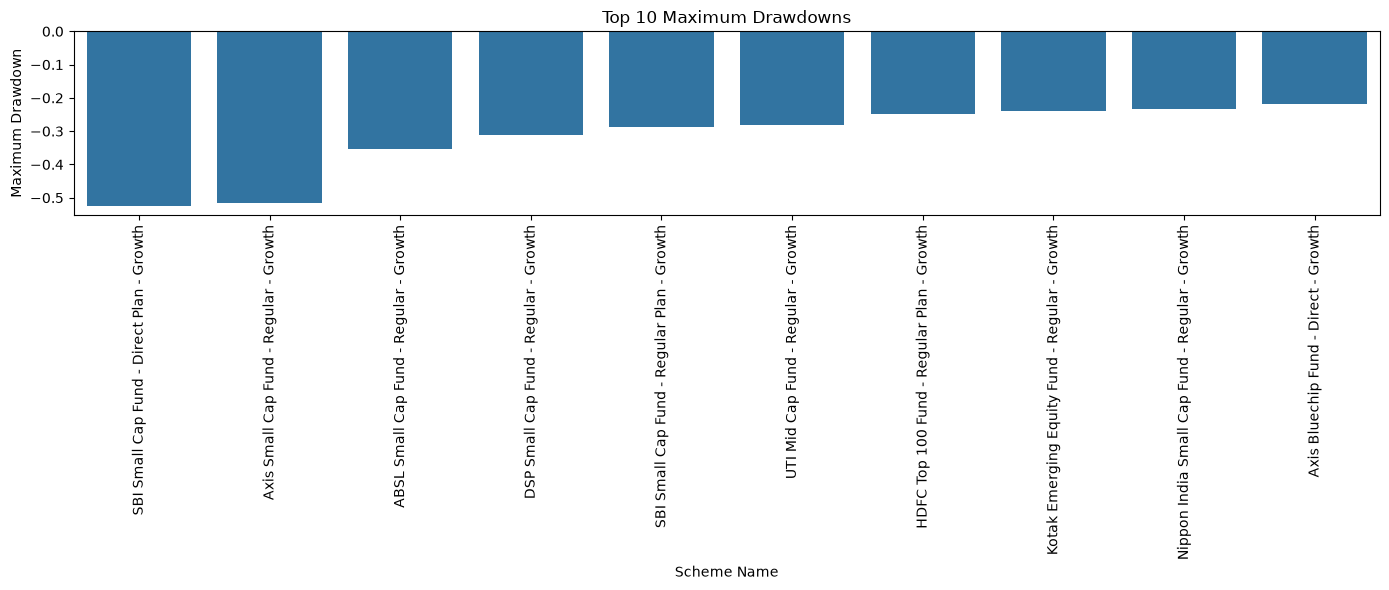

In [73]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=max_dd.head(10),
    x="scheme_name",
    y="max_drawdown"
)

plt.xticks(rotation=90)

plt.title("Top 10 Maximum Drawdowns")

plt.xlabel("Scheme Name")

plt.ylabel("Maximum Drawdown")

plt.tight_layout()

plt.savefig("../reports/charts/max_drawdown.png", dpi=300)

plt.show()

#### Worst Drawdown Date Range

In [74]:
worst_drawdown = nav.loc[
    nav.groupby("amfi_code")["drawdown"].idxmin(),
    ["amfi_code", "date", "drawdown"]
]

worst_drawdown = worst_drawdown.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

worst_drawdown.head()

,amfi_code,date,drawdown,scheme_name
0,100016,2022-09-15,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,2023-07-28,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,2022-05-12,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,2023-07-05,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,2026-05-11,-0.354469,ABSL Small Cap Fund - Regular - Growth


## Fund Scorecard

#### Required Columns

In [75]:
scorecard = performance[[
    "amfi_code",
    "scheme_name",
    "return_3yr_pct",
    "expense_ratio_pct"
]].copy()

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77


#### Merge Sharpe Ratio

In [78]:
scorecard = scorecard.merge(

    sharpe_df[["amfi_code", "Sharpe_Ratio"]],

    on="amfi_code",

    how="left"

)

#### Merge Alpha

In [85]:
scorecard = scorecard.merge(

    alpha_beta_df[["amfi_code", "alpha"]],

    on="amfi_code",

    how="left"

)

#### Merge Maximum Drawdown

In [86]:
scorecard = scorecard.merge(

    max_dd[["amfi_code", "max_drawdown"]],

    on="amfi_code",

    how="left"

)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,return_rank,sharpe_rank,alpha,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,26.0,4.0,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,34.0,12.0,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,1.0,14.0,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,2.0,32.0,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,38.0,37.0,0.056209,-0.043287


#### Create Ranks

In [88]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

#### Composite Score

In [89]:
scorecard["score"] = (

    scorecard["return_rank"] * 0.30 +

    scorecard["sharpe_rank"] * 0.25 +

    scorecard["alpha_rank"] * 0.20 +

    scorecard["expense_rank"] * 0.15 +

    scorecard["drawdown_rank"] * 0.10

)

#### Convert into 0–100 Score

In [90]:
scorecard["fund_score"] = 100 * (

    scorecard["score"].max() - scorecard["score"]

) / (

    scorecard["score"].max() - scorecard["score"].min()

)

#### Final Ranking

In [91]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,return_rank,sharpe_rank,alpha,max_drawdown,alpha_rank,expense_rank,drawdown_rank,score,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,8.0,5.0,0.292636,-0.181885,3.0,15.0,25.0,9.000,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,11.0,2.0,0.273305,-0.129740,5.0,22.0,13.0,9.400,98.143852
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,10.0,7.0,0.271954,-0.162172,6.0,17.0,20.0,10.500,93.039443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,1.0,14.0,0.303370,-0.287060,1.0,21.0,36.0,10.750,91.879350
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,17.0,1.0,0.269838,-0.112657,7.0,23.0,8.0,11.000,90.719258
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,6.0,13.0,0.300579,-0.311719,2.0,26.5,37.0,13.125,80.858469
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,9.0,6.0,0.265986,-0.172481,8.0,38.0,22.0,13.700,78.190255
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,20.0,10.0,0.211948,-0.125883,13.0,12.0,12.0,14.100,76.334107
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,15.0,11.0,0.260767,-0.209609,9.0,17.0,28.0,14.400,74.941995
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,23.0,3.0,0.282704,-0.163967,4.0,36.5,21.0,16.025,67.401392


#### Save CSV

In [92]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

#### Visualization

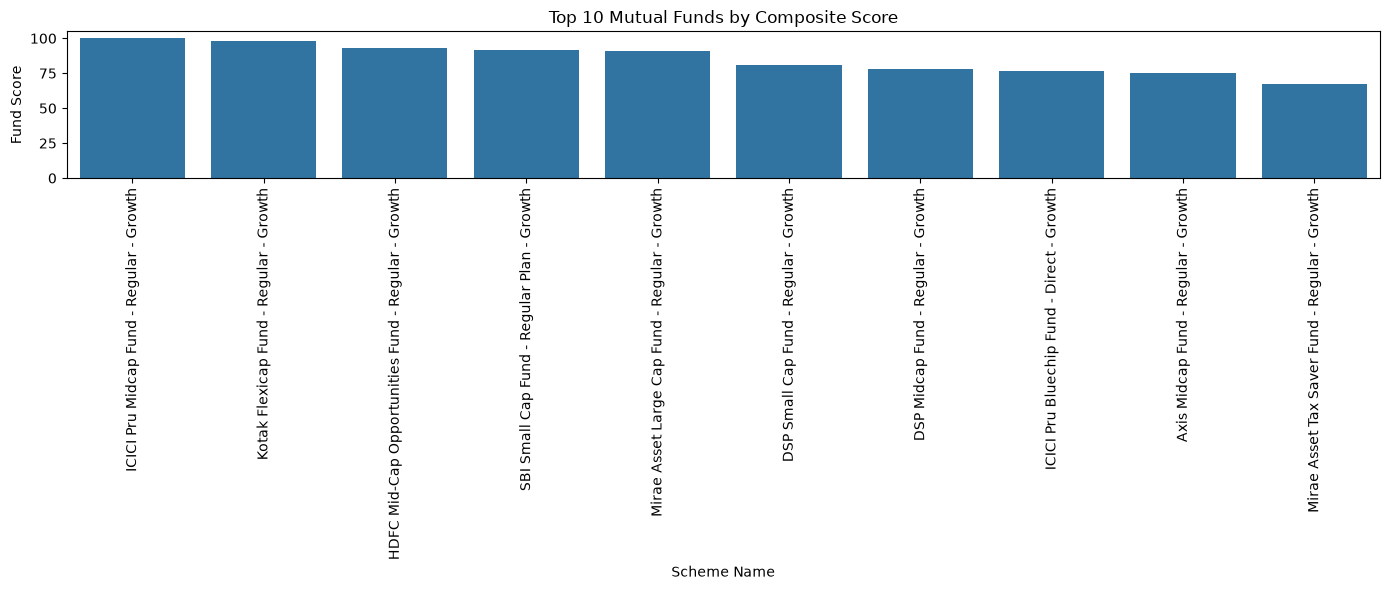

In [93]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=scorecard.head(10),
    x="scheme_name",
    y="fund_score"
)

plt.xticks(rotation=90)

plt.title("Top 10 Mutual Funds by Composite Score")

plt.xlabel("Scheme Name")

plt.ylabel("Fund Score")

plt.tight_layout()

plt.savefig("../reports/charts/fund_scorecard.png", dpi=300)

plt.show()

## Benchmark Comparison

In [94]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()

top5_codes

[120505, 120843, 100033, 119598, 148567]

#### Filter NAV Data

In [95]:
top5_nav = nav[nav["amfi_code"].isin(top5_codes)].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
2300,100033,2022-01-03,107.3758,NaN,107.3758,0.000000
2301,100033,2022-01-04,105.9447,-0.013328,107.3758,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386,107.3758,-0.017656
2303,100033,2022-01-06,104.9350,-0.005167,107.3758,-0.022731
2304,100033,2022-01-07,104.3318,-0.005748,107.3758,-0.028349


#### Normalize NAV

In [96]:
top5_nav["normalized_nav"] = top5_nav.groupby("amfi_code")["nav"].transform(
    lambda x: x / x.iloc[0] * 100
)

#### Prepare Benchmarks

In [97]:
benchmark_compare = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_compare["normalized_close"] = benchmark_compare.groupby("index_name")[
    "close_value"
].transform(lambda x: x / x.iloc[0] * 100)

#### Plot Top 5 Funds

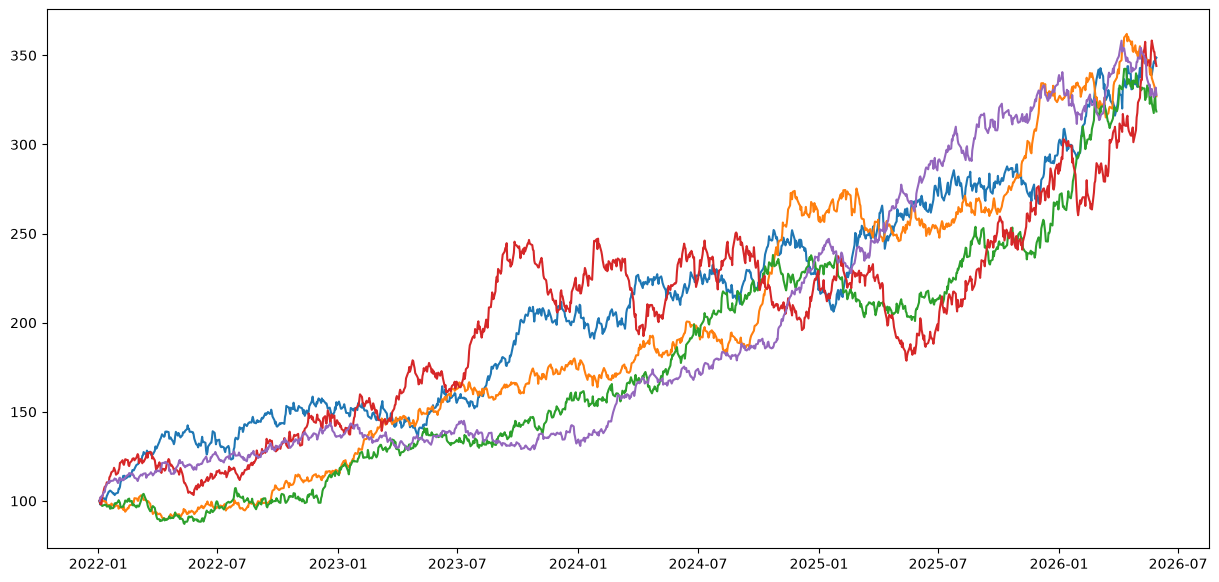

In [98]:
plt.figure(figsize=(15,7))

for code in top5_codes:

    temp = top5_nav[top5_nav["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=str(code)
    )

#### Plot Benchmarks

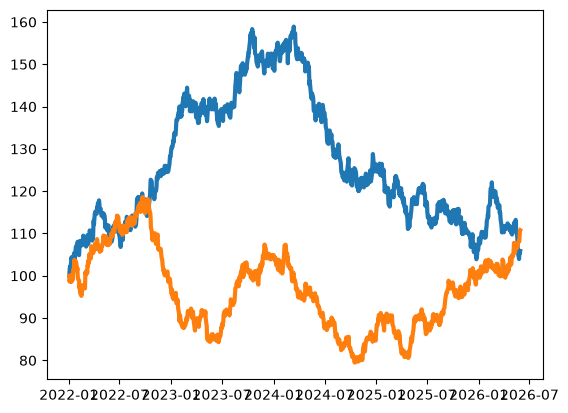

In [99]:
for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_compare[
        benchmark_compare["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["normalized_close"],
        linewidth=3,
        label=index
    )

#### Finalize Chart

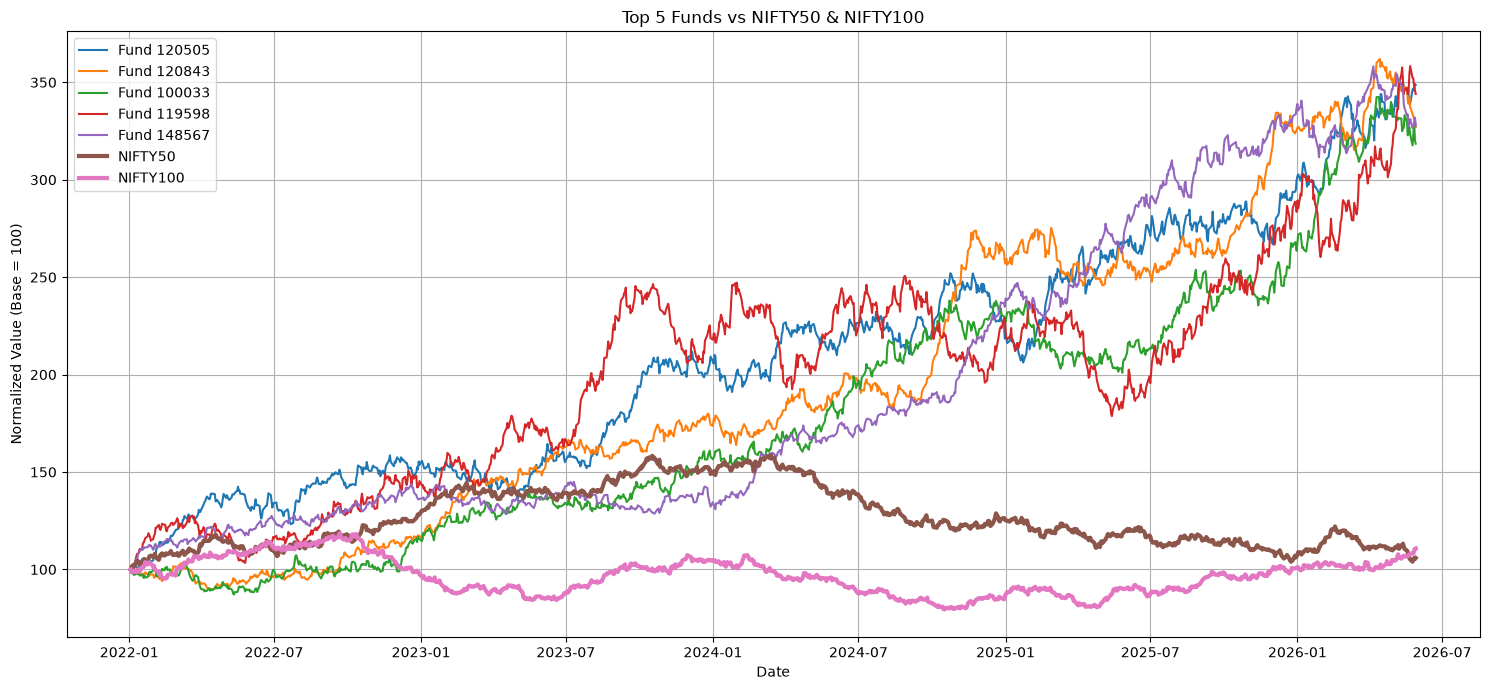

In [108]:
plt.figure(figsize=(15,7))

# Top 5 Funds
for code in top5_codes:
    temp = top5_nav[top5_nav["amfi_code"] == code]
    plt.plot(
        temp["date"].values,
        temp["normalized_nav"].values,
        label=f"Fund {code}"
    )

# Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:
    temp = benchmark_compare[benchmark_compare["index_name"] == idx]
    plt.plot(
        temp["date"].values,
        temp["normalized_close"].values,
        linewidth=3,
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300
)

plt.show()

#### Tracking Error

In [115]:
tracking_error = []

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

for code in top5_codes:

    fund_nav = nav[
        nav["amfi_code"] == code
    ].copy()

    fund_nav["fund_return"] = fund_nav["nav"].pct_change()

    merged = pd.merge(
        fund_nav,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    te = (
        (merged["fund_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error.append({
        "amfi_code": code,
        "tracking_error": te
    })

#### Tracking Error Table

In [116]:
tracking_error_df = pd.DataFrame(tracking_error)

tracking_error_df = tracking_error_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

tracking_error_df

,amfi_code,tracking_error,scheme_name
0,120505,0.231968,ICICI Pru Midcap Fund - Regular - Growth
1,120843,0.206425,Kotak Flexicap Fund - Regular - Growth
2,100033,0.228699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,119598,0.283881,SBI Small Cap Fund - Regular Plan - Growth
4,148567,0.189664,Mirae Asset Large Cap Fund - Regular - Growth


#### Save CSV

In [117]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)